In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)

In [8]:
print("=" * 60)
print("  STUDENT PERFORMANCE PREDICTION SYSTEM")
print("=" * 60)
print("\n[STEP 1] Loading Dataset...")

df = pd.read_csv(r'D:\student\student_performance.csv')

print(f"Dataset loaded successfully! Shape: {df.shape}")
print(df.head())

  STUDENT PERFORMANCE PREDICTION SYSTEM

[STEP 1] Loading Dataset...
Dataset loaded successfully! Shape: (300, 7)
  Student_ID  Study_Hours  Attendance  Previous_Marks  Assignments  \
0    STU0001          4.4        43.1            41.8         44.6   
1    STU0002          9.6        71.9            49.5         31.9   
2    STU0003          7.6        72.4            42.4         42.7   
3    STU0004          6.4        78.2            36.2         70.8   
4    STU0005          2.4        83.6            38.4         59.5   

   Internal_Marks Final_Result  
0            40.3         Fail  
1            11.0         Pass  
2            10.9         Fail  
3            22.9         Fail  
4            29.5         Fail  


In [9]:
print("\n[STEP 2] Data Preprocessing...")

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop Student_ID (not a feature)
df = df.drop('Student_ID', axis=1)

# Encode target variable: Final_Result → numbers
le = LabelEncoder()
df['Final_Result_Encoded'] = le.fit_transform(df['Final_Result'])

print(f"\nClass Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("\nData after preprocessing:")
print(df.head())



[STEP 2] Data Preprocessing...

Missing Values:
Student_ID        0
Study_Hours       0
Attendance        0
Previous_Marks    0
Assignments       0
Internal_Marks    0
Final_Result      0
dtype: int64

Class Encoding: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'Fail': np.int64(3), 'Pass': np.int64(4)}

Data after preprocessing:
   Study_Hours  Attendance  Previous_Marks  Assignments  Internal_Marks  \
0          4.4        43.1            41.8         44.6            40.3   
1          9.6        71.9            49.5         31.9            11.0   
2          7.6        72.4            42.4         42.7            10.9   
3          6.4        78.2            36.2         70.8            22.9   
4          2.4        83.6            38.4         59.5            29.5   

  Final_Result  Final_Result_Encoded  
0         Fail                     3  
1         Pass                     4  
2         Fail                     3  
3         Fail                     3  
4         F


[STEP 3] Exploratory Data Analysis (EDA)...


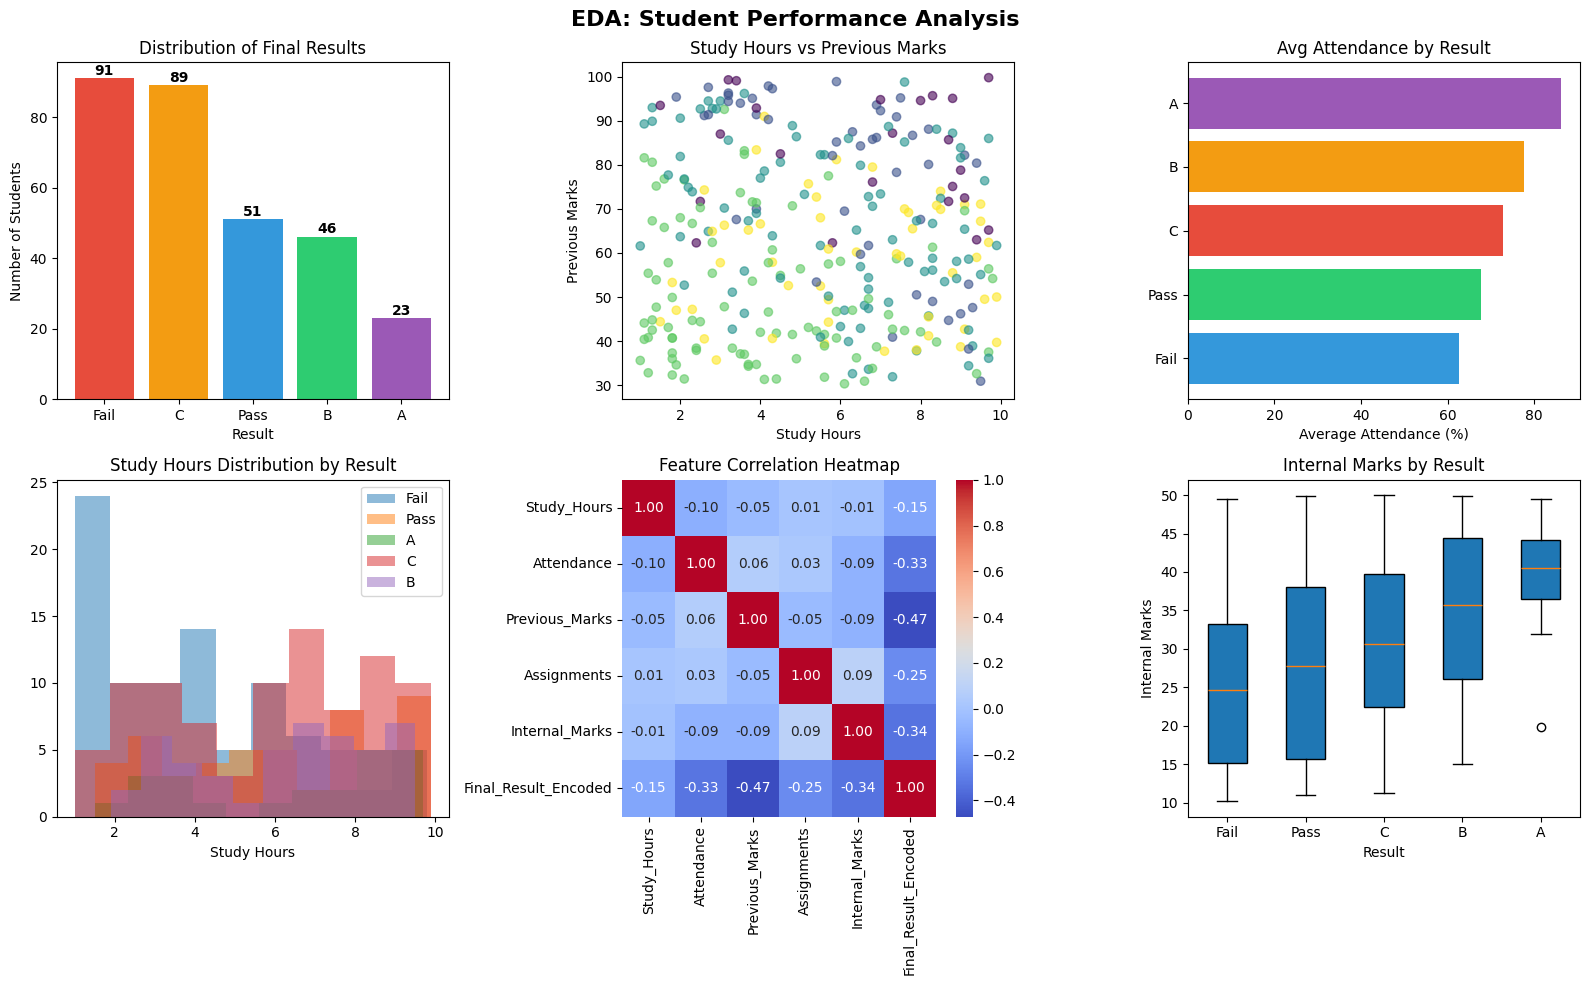

EDA plots saved as 'eda_plots.png'


In [10]:
print("\n[STEP 3] Exploratory Data Analysis (EDA)...")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA: Student Performance Analysis', fontsize=16, fontweight='bold')

# 1. Result Distribution
result_counts = df['Final_Result'].value_counts()
axes[0, 0].bar(result_counts.index, result_counts.values,
               color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6'])
axes[0, 0].set_title('Distribution of Final Results')
axes[0, 0].set_xlabel('Result')
axes[0, 0].set_ylabel('Number of Students')
for i, v in enumerate(result_counts.values):
    axes[0, 0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# 2. Study Hours vs Marks
axes[0, 1].scatter(df['Study_Hours'], df['Previous_Marks'],
                   c=df['Final_Result_Encoded'], cmap='viridis', alpha=0.6)
axes[0, 1].set_title('Study Hours vs Previous Marks')
axes[0, 1].set_xlabel('Study Hours')
axes[0, 1].set_ylabel('Previous Marks')

# 3. Attendance vs Result
avg_attendance = df.groupby('Final_Result')['Attendance'].mean().sort_values()
axes[0, 2].barh(avg_attendance.index, avg_attendance.values,
                color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'])
axes[0, 2].set_title('Avg Attendance by Result')
axes[0, 2].set_xlabel('Average Attendance (%)')

# 4. Study Hours Distribution by Result
for result in df['Final_Result'].unique():
    subset = df[df['Final_Result'] == result]['Study_Hours']
    axes[1, 0].hist(subset, alpha=0.5, label=result, bins=10)
axes[1, 0].set_title('Study Hours Distribution by Result')
axes[1, 0].set_xlabel('Study Hours')
axes[1, 0].legend()

# 5. Correlation Heatmap
numeric_df = df.drop('Final_Result', axis=1)
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlation Heatmap')

# 6. Internal Marks vs Result (Boxplot)
result_order = ['Fail', 'Pass', 'C', 'B', 'A']
data_to_plot = [df[df['Final_Result'] == r]['Internal_Marks'].values for r in result_order]
axes[1, 2].boxplot(data_to_plot, labels=result_order, patch_artist=True)
axes[1, 2].set_title('Internal Marks by Result')
axes[1, 2].set_xlabel('Result')
axes[1, 2].set_ylabel('Internal Marks')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved as 'eda_plots.png'")

In [12]:
print("\n[STEP 4] Feature Selection...")

# Features as per PDF synopsis
features = ['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks']
target = 'Final_Result_Encoded'

X = df[features]
y = df[target]

print(f"Selected Features: {features}")
print(f"Target: Final_Result")
print(f"X shape: {X.shape}, y shape: {y.shape}")


[STEP 4] Feature Selection...
Selected Features: ['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks']
Target: Final_Result
X shape: (300, 5), y shape: (300,)


In [13]:
print("\n[STEP 5] Splitting dataset (80% Train / 20% Test)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



[STEP 5] Splitting dataset (80% Train / 20% Test)...
Training samples: 240
Testing samples:  60


In [14]:
print("\n[STEP 6] Training Multiple ML Models...")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes':         GaussianNB(),
    'SVM':                 SVC(kernel='rbf', random_state=42)
}

results = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[model_name] = {
        'Accuracy': round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2),
        'F1-Score': round(f1 * 100, 2),
        'model': model,
        'y_pred': y_pred
    }

    print(f"\n--- {model_name} ---")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  Precision: {prec*100:.2f}%")
    print(f"  Recall   : {rec*100:.2f}%")
    print(f"  F1-Score : {f1*100:.2f}%")


[STEP 6] Training Multiple ML Models...

--- Logistic Regression ---
  Accuracy : 68.33%
  Precision: 65.55%
  Recall   : 68.33%
  F1-Score : 65.95%

--- Decision Tree ---
  Accuracy : 51.67%
  Precision: 55.30%
  Recall   : 51.67%
  F1-Score : 52.36%

--- Random Forest ---
  Accuracy : 61.67%
  Precision: 63.63%
  Recall   : 61.67%
  F1-Score : 61.10%

--- Naive Bayes ---
  Accuracy : 56.67%
  Precision: 57.92%
  Recall   : 56.67%
  F1-Score : 54.97%

--- SVM ---
  Accuracy : 70.00%
  Precision: 68.48%
  Recall   : 70.00%
  F1-Score : 68.26%



[STEP 7] Model Evaluation...

Model Comparison Table:
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression     68.33      65.55   68.33     65.95
Decision Tree           51.67      55.30   51.67     52.36
Random Forest           61.67      63.63   61.67     61.10
Naive Bayes             56.67      57.92   56.67     54.97
SVM                     70.00      68.48   70.00     68.26

✅ Best Model: SVM (70.0% Accuracy)


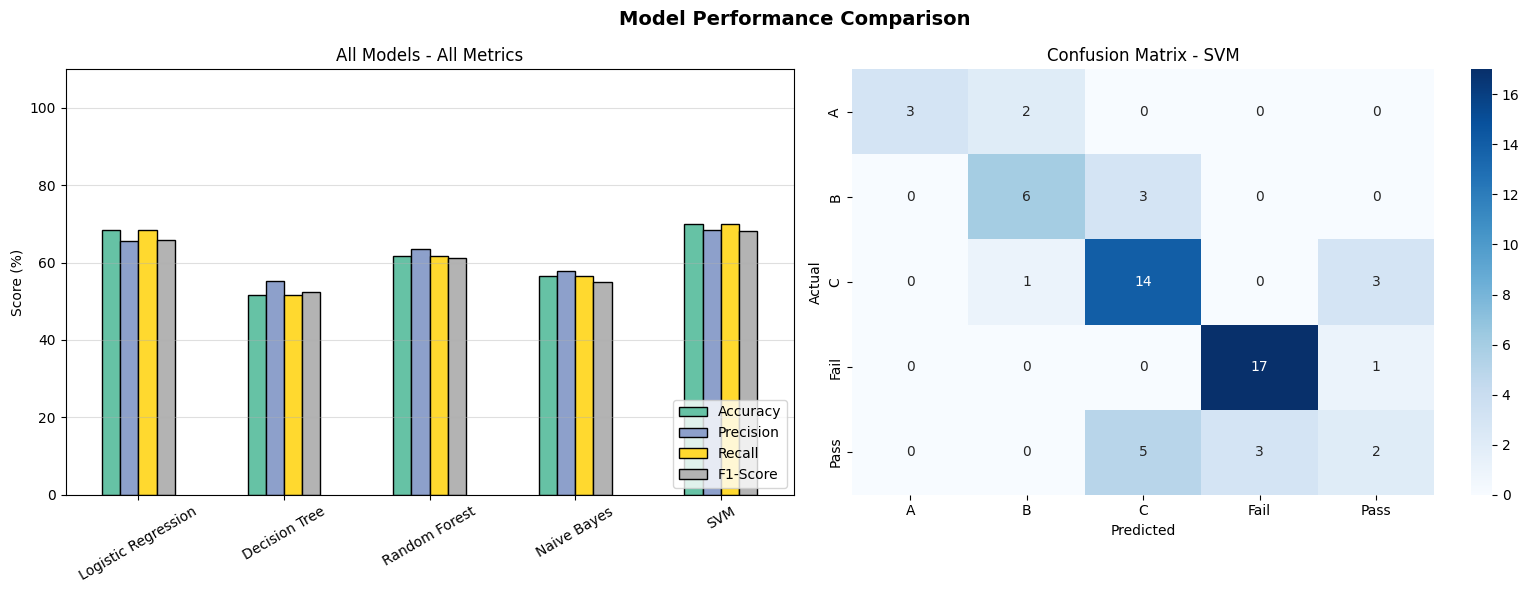

Model evaluation plots saved as 'model_evaluation.png'

Detailed Classification Report (SVM):
              precision    recall  f1-score   support

           A       1.00      0.60      0.75         5
           B       0.67      0.67      0.67         9
           C       0.64      0.78      0.70        18
        Fail       0.85      0.94      0.89        18
        Pass       0.33      0.20      0.25        10

    accuracy                           0.70        60
   macro avg       0.70      0.64      0.65        60
weighted avg       0.68      0.70      0.68        60



In [15]:
print("\n[STEP 7] Model Evaluation...")

# Best model
metrics_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k not in ['model', 'y_pred']}
    for name, vals in results.items()
}).T

print("\nModel Comparison Table:")
print(metrics_df.to_string())

best_model_name = metrics_df['Accuracy'].idxmax()
best_model = results[best_model_name]['model']
best_y_pred = results[best_model_name]['y_pred']
print(f"\n✅ Best Model: {best_model_name} ({metrics_df['Accuracy'].max()}% Accuracy)")

# Plot: Model Comparison Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

metrics_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=axes[0], colormap='Set2', edgecolor='black', rot=30
)
axes[0].set_title('All Models - All Metrics')
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(0, 110)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.4)

# Plot: Confusion Matrix for Best Model
cm = confusion_matrix(y_test, best_y_pred)
class_names = le.classes_
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title(f'Confusion Matrix - {best_model_name}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model evaluation plots saved as 'model_evaluation.png'")

# Full classification report
print(f"\nDetailed Classification Report ({best_model_name}):")
print(classification_report(y_test, best_y_pred, target_names=le.classes_))



[STEP 8] Feature Importance (Random Forest)...
          Feature  Importance
2  Previous_Marks    0.241774
0     Study_Hours    0.203344
4  Internal_Marks    0.199400
1      Attendance    0.183244
3     Assignments    0.172239


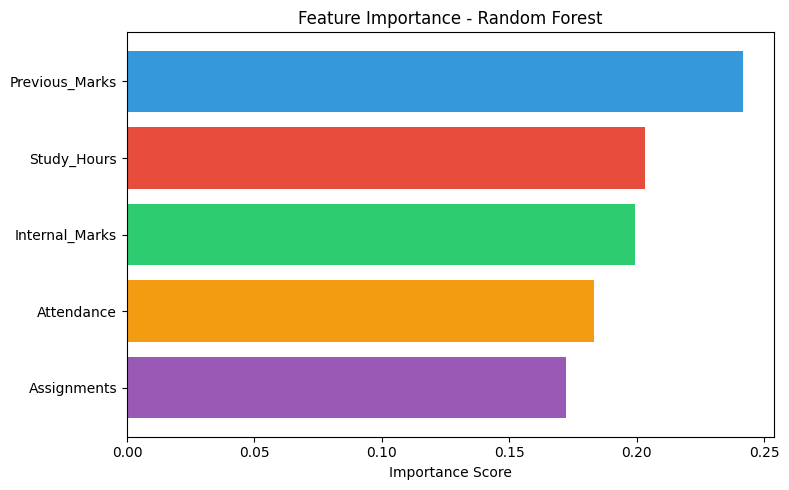

Feature importance plot saved as 'feature_importance.png'


In [16]:
print("\n[STEP 8] Feature Importance (Random Forest)...")

rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feat_imp_df)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
         color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'])
plt.xlabel('Importance Score')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance plot saved as 'feature_importance.png'")


In [17]:
print("\n[STEP 9] Predict Performance for New Students...")

new_students = pd.DataFrame({
    'Study_Hours':    [8.0, 2.0, 5.5, 1.0],
    'Attendance':     [90.0, 45.0, 70.0, 55.0],
    'Previous_Marks': [85.0, 35.0, 60.0, 40.0],
    'Assignments':    [80.0, 30.0, 65.0, 45.0],
    'Internal_Marks': [40.0, 15.0, 28.0, 20.0],
})

new_students_scaled = scaler.transform(new_students)
predictions_encoded = best_model.predict(new_students_scaled)
predictions_label   = le.inverse_transform(predictions_encoded)

new_students['Predicted_Result'] = predictions_label

print("\nNew Student Predictions (using best model: {})".format(best_model_name))
print(new_students.to_string(index=False))


[STEP 9] Predict Performance for New Students...

New Student Predictions (using best model: SVM)
 Study_Hours  Attendance  Previous_Marks  Assignments  Internal_Marks Predicted_Result
         8.0        90.0            85.0         80.0            40.0                A
         2.0        45.0            35.0         30.0            15.0             Fail
         5.5        70.0            60.0         65.0            28.0                C
         1.0        55.0            40.0         45.0            20.0             Fail


In [18]:
print("\n[STEP 10] Identifying At-Risk Students...")

df_original = pd.read_csv('student_performance.csv')
X_all = df_original[features]
X_all_scaled = scaler.transform(X_all)
df_original['Predicted_Result'] = le.inverse_transform(best_model.predict(X_all_scaled))
at_risk = df_original[df_original['Predicted_Result'] == 'Fail']

print(f"\nTotal students predicted to FAIL: {len(at_risk)}")
print("\nAt-Risk Students:")
print(at_risk[['Student_ID', 'Study_Hours', 'Attendance', 'Previous_Marks', 'Predicted_Result']].head(10).to_string(index=False))

at_risk.to_csv('at_risk_students.csv', index=False)
print("\nAt-risk student list saved to 'at_risk_students.csv'")

print("\n" + "=" * 60)
print("  PROJECT COMPLETE!")
print("=" * 60)
print(f"  Best Model     : {best_model_name}")
print(f"  Best Accuracy  : {metrics_df['Accuracy'].max()}%")
print(f"  At-Risk Students Identified: {len(at_risk)}")
print("\n  Output Files:")
print("  1. eda_plots.png           - Exploratory Data Analysis")
print("  2. model_evaluation.png    - Model Comparison + Confusion Matrix")
print("  3. feature_importance.png  - Feature Importance Chart")
print("  4. at_risk_students.csv    - List of At-Risk Students")
print("=" * 60)


[STEP 10] Identifying At-Risk Students...

Total students predicted to FAIL: 94

At-Risk Students:
Student_ID  Study_Hours  Attendance  Previous_Marks Predicted_Result
   STU0001          4.4        43.1            41.8             Fail
   STU0002          9.6        71.9            49.5             Fail
   STU0003          7.6        72.4            42.4             Fail
   STU0004          6.4        78.2            36.2             Fail
   STU0005          2.4        83.6            38.4             Fail
   STU0007          1.5        71.0            44.4             Fail
   STU0011          1.2        66.3            32.8             Fail
   STU0014          2.9        97.8            35.7             Fail
   STU0017          3.7        64.5            34.3             Fail
   STU0020          3.6        55.0            82.4             Fail

At-risk student list saved to 'at_risk_students.csv'

  PROJECT COMPLETE!
  Best Model     : SVM
  Best Accuracy  : 70.0%
  At-Risk Students